## 1. Setup and Installation

In [1]:
# ============================================================
# Smart Surveillance & Crowd Analytics System
# Lab #14 — Complex Computing Activity
# Roll No: 23-ai-26, 23-ai-04, 23-ai-50
# ============================================================

# Install YOLOv8 (ultralytics) and supervision (helper for annotations)
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:00


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files
from google.colab.patches import cv2_imshow   # Colab can't use cv2.imshow() directly
import os, time, math
from collections import defaultdict, deque

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 2. Video Data Loading

In [3]:
# Upload your video file from local machine into Colab
uploaded = files.upload()
VIDEO_PATH = list(uploaded.keys())[0]
print(f"✅ Uploaded: {VIDEO_PATH}")

Saving YTDown_YouTube_HD-CCTV-Camera-video-3MP-4MP-iProx-CCTV-_Media_KMJS66jBtVQ_001_720p.mp4 to YTDown_YouTube_HD-CCTV-Camera-video-3MP-4MP-iProx-CCTV-_Media_KMJS66jBtVQ_001_720p.mp4
✅ Uploaded: YTDown_YouTube_HD-CCTV-Camera-video-3MP-4MP-iProx-CCTV-_Media_KMJS66jBtVQ_001_720p.mp4


## 3. Video Metadata Analysis

In [4]:
cap = cv2.VideoCapture(VIDEO_PATH)

# Read video metadata using CAP_PROP constants
FRAME_WIDTH  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
FRAME_HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS          = cap.get(cv2.CAP_PROP_FPS)
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
DURATION     = TOTAL_FRAMES / FPS

cap.release()  # Always release after reading metadata — frees the file handle

print(f"Resolution  : {FRAME_WIDTH} x {FRAME_HEIGHT}")
print(f"FPS         : {FPS:.2f}")
print(f"Total Frames: {TOTAL_FRAMES}")
print(f"Duration    : {DURATION:.2f} seconds")

Resolution  : 1270 x 720
FPS         : 13.09
Total Frames: 1283
Duration    : 97.99 seconds


## 4. Classical CV Preprocessing Chain

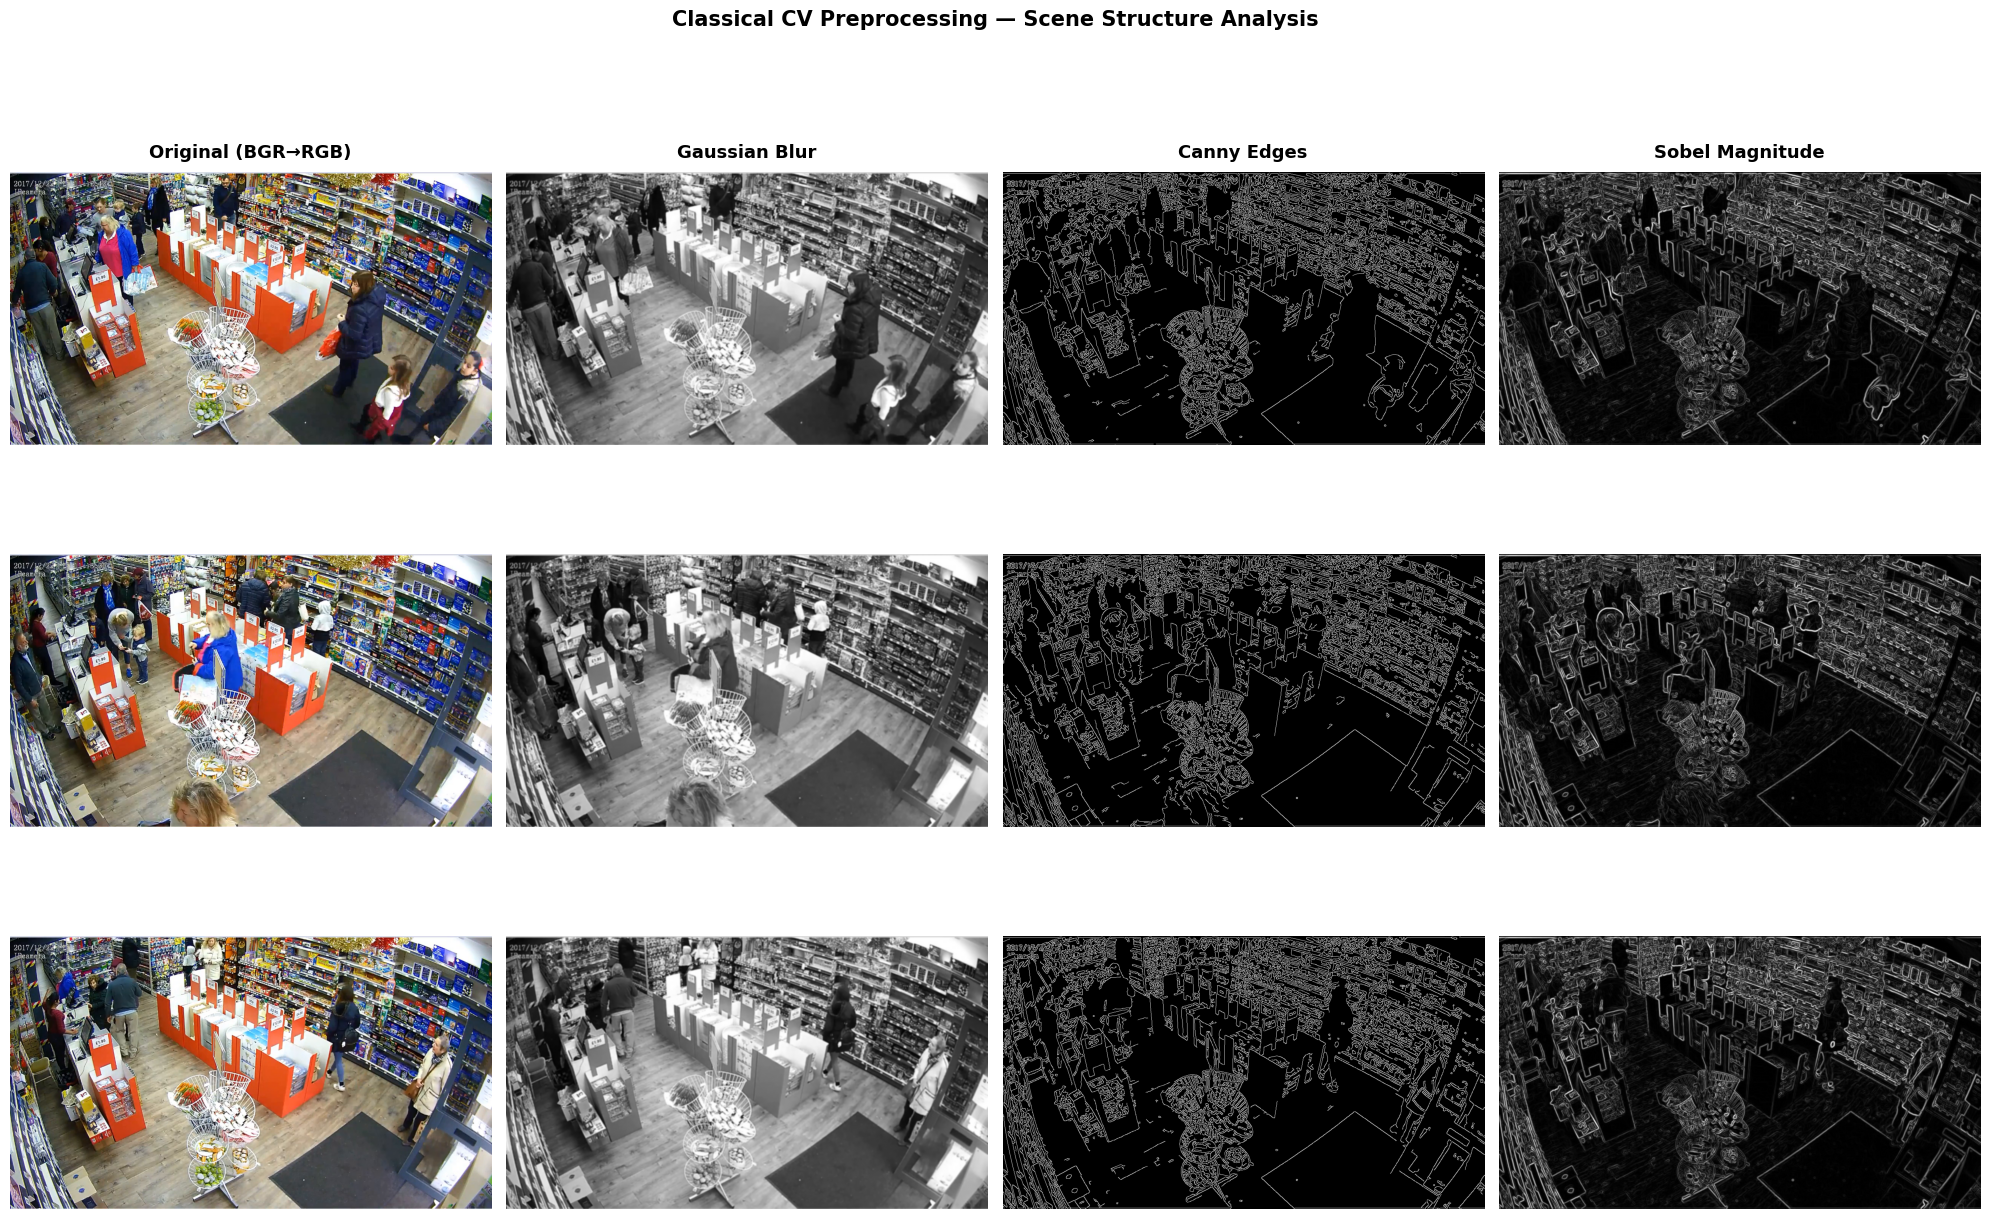

✅ Saved: classical_cv_analysis.png


In [5]:
def extract_sample_frames(video_path, n=5):
    """
    Extract n evenly spaced frames from the video.
    We space them evenly instead of taking the first n frames because
    the first few frames of surveillance footage are often static or empty.
    """
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # np.linspace gives n evenly spaced values from 0 to total-1
    indices = np.linspace(0, total - 1, n, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)  # Seek to specific frame
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
    cap.release()
    return frames


def apply_classical_cv(frame):
    """
    Full classical CV preprocessing chain.
    Returns: (gray, blurred, canny_edges, sobel_magnitude)
    """
    # Step 1: Convert to grayscale
    # Edge detection operates on single-channel intensity, not color.
    # Color channels would create 3x the computation for no benefit here.
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Step 2: Gaussian Blur
    # ksize=(5,5) — 5x5 kernel. Must be odd integers. Larger = more blur.
    # sigmaX=1.5 — controls the bell curve spread. 0 = auto-calculate from ksize.
    # WHY blur before edge detection? Noise (random pixel variation) creates
    # false edges. Blur averages neighboring pixels, suppressing noise gradients
    # so only real structural edges survive.
    blurred = cv2.GaussianBlur(gray, ksize=(5, 5), sigmaX=1.5)

    # Step 3: Canny Edge Detection
    # threshold1=50 (lower hysteresis): gradients below this are discarded
    # threshold2=150 (upper hysteresis): gradients above this are definite edges
    # Gradients between 50–150 are kept ONLY if they connect to a strong edge.
    # This two-threshold system (Canny's key innovation) removes isolated weak
    # noise edges while preserving genuine fine detail connected to strong edges.
    canny = cv2.Canny(blurred, threshold1=50, threshold2=150)

    # Step 4: Sobel — computes directional gradients
    # dx=1, dy=0: gradient in X direction (vertical edges)
    # dx=0, dy=1: gradient in Y direction (horizontal edges)
    # ksize=3: 3x3 Sobel kernel (standard choice, odd number required)
    # cv2.CV_64F: output as 64-bit float to avoid clipping negative gradients
    sobelX = cv2.Sobel(blurred, cv2.CV_64F, dx=1, dy=0, ksize=3)
    sobelY = cv2.Sobel(blurred, cv2.CV_64F, dx=0, dy=1, ksize=3)

    # Combine X and Y gradients: magnitude = sqrt(Gx² + Gy²)
    # This gives total edge strength regardless of direction
    sobel_mag = cv2.magnitude(sobelX, sobelY)

    # Normalize to 0–255 for display (magnitude values can exceed 255)
    sobel_norm = cv2.normalize(sobel_mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    return gray, blurred, canny, sobel_norm


# --- Visualize on 3 sample frames ---
sample_frames = extract_sample_frames(VIDEO_PATH, n=3)

fig, axes = plt.subplots(3, 4, figsize=(20, 13))
col_titles = ['Original (BGR→RGB)', 'Gaussian Blur', 'Canny Edges', 'Sobel Magnitude']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight='bold', pad=10)

for row, frame in enumerate(sample_frames):
    gray, blurred, canny, sobel = apply_classical_cv(frame)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # matplotlib expects RGB not BGR

    axes[row, 0].imshow(rgb)
    axes[row, 1].imshow(blurred, cmap='gray')
    axes[row, 2].imshow(canny, cmap='gray')
    axes[row, 3].imshow(sobel, cmap='gray')

    for ax in axes[row]:
        ax.axis('off')

plt.suptitle('Classical CV Preprocessing — Scene Structure Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('classical_cv_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: classical_cv_analysis.png")

## 5. YOLOv8 Object Detection Setup

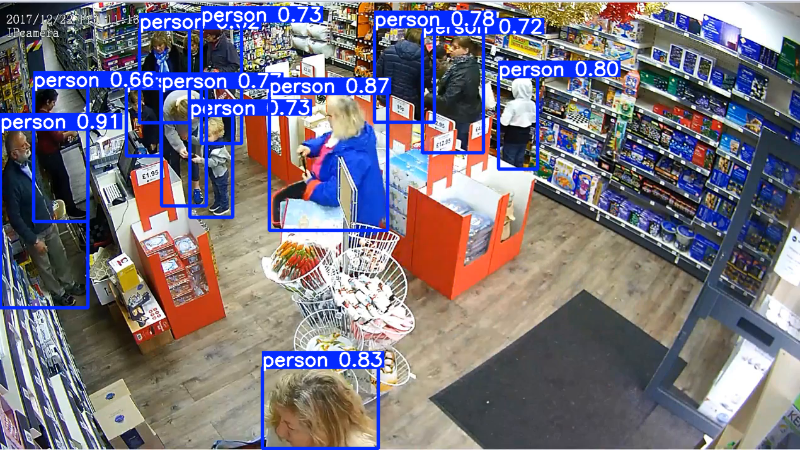

✅ Detected 12 person(s) in test frame
   Confidence scores: [       0.91        0.87        0.83         0.8        0.78        0.77        0.73        0.73        0.72        0.66        0.62        0.45]


In [8]:
# Load YOLOv8 nano model
# 'yolov8n.pt' will auto-download (~6MB) on first run
# Nano (n) is the fastest variant. The size ladder is: n < s < m < l < x
# On Colab CPU, nano gives ~3-8 FPS. On T4 GPU it gives ~30+ FPS.
model = YOLO('yolo11x.pt')

# Test inference on one sample frame to verify detection works
test_frame = sample_frames[1].copy()

results = model(
    test_frame,
    classes=[0],    # Class 0 = 'person' in COCO dataset (80 classes total)
    conf=0.30,       # Confidence threshold: discard detections below 40% confidence
    imgsz=640,      # Input image resized to 640x640 internally by YOLO
    verbose=False   # Suppress per-frame console output
)

# results[0].plot() returns the frame with drawn boxes (BGR numpy array)
annotated_test = results[0].plot()
cv2_imshow(cv2.resize(annotated_test, (800, 450)))

n_detected = len(results[0].boxes)
print(f"✅ Detected {n_detected} person(s) in test frame")
print(f"   Confidence scores: {results[0].boxes.conf.cpu().numpy().round(2)}")

## 6. Monitored Zone Configuration

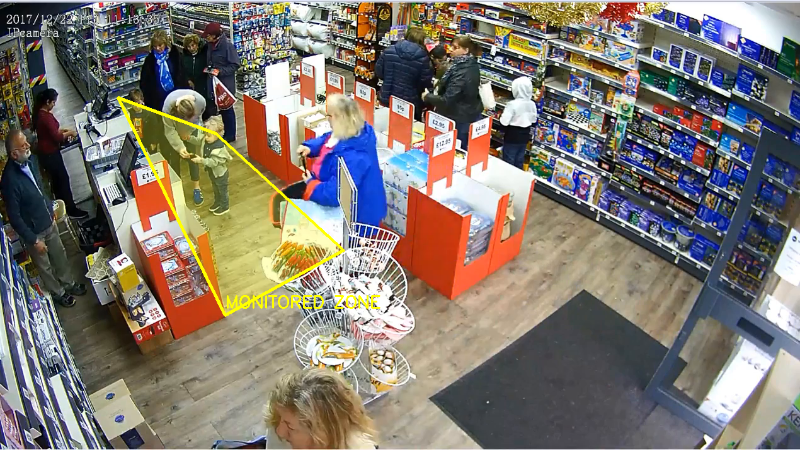

⬆ Preview of zone. If it doesn't cover the right area, adjust ZONE_POINTS above.


In [14]:
# ⚠️ IMPORTANT: Adjust these coordinates to match YOUR video.
# Print FRAME_WIDTH and FRAME_HEIGHT from Cell 4, then set the polygon
# to enclose the area you want to monitor (e.g., an entrance, a corridor).

# Default: a trapezoid covering the center-lower portion of the frame.
# Coordinates are (x, y) pixel positions, origin at TOP-LEFT corner.
# ZONE_POINTS = np.array([
#     [int(FRAME_WIDTH * 0.40), int(FRAME_HEIGHT * 0.40)],  # top-left
#     [int(FRAME_WIDTH * 0.80), int(FRAME_HEIGHT * 0.40)],  # top-right
#     [int(FRAME_WIDTH * 0.90), int(FRAME_HEIGHT * 0.90)],  # bottom-right
#     [int(FRAME_WIDTH * 0.40), int(FRAME_HEIGHT * 0.90)],  # bottom-left
# ], dtype=np.int32)

# ZONE_POINTS = np.array([
#     [int(FRAME_WIDTH * 0.20), int(FRAME_HEIGHT * 0.40)],  # top-left
#     [int(FRAME_WIDTH * 0.80), int(FRAME_HEIGHT * 0.40)],  # top-right
#     [int(FRAME_WIDTH * 0.90), int(FRAME_HEIGHT * 0.90)],  # bottom-right
#     [int(FRAME_WIDTH * 0.10), int(FRAME_HEIGHT * 0.90)],  # bottom-left
# ], dtype=np.int32)
ZONE_POINTS = np.array([
    [ 357,  504],   # top-left
    [ 545,  400],   # top-right
    [ 342,  213],   # bottom-right
    [ 187,  156],   # bottom-left
], dtype=np.int32)
# Trigger alert when more than this many people are inside the zone simultaneously
ALERT_THRESHOLD = 5

# --- Preview the zone on a sample frame ---
zone_preview = sample_frames[1].copy()
overlay = zone_preview.copy()

# Semi-transparent fill: draw on overlay, then blend with original
cv2.fillPoly(overlay, [ZONE_POINTS], color=(0, 255, 255))  # Yellow fill
cv2.addWeighted(overlay, 0.25, zone_preview, 0.75, 0, zone_preview)

# Zone boundary outline (thick, cyan)
cv2.polylines(zone_preview, [ZONE_POINTS], isClosed=True,
              color=(0, 255, 255), thickness=3)

# Label above the zone
cv2.putText(zone_preview, "MONITORED ZONE",
            (ZONE_POINTS[0][0], ZONE_POINTS[0][1] - 12),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)

cv2_imshow(cv2.resize(zone_preview, (800, 450)))
print("⬆ Preview of zone. If it doesn't cover the right area, adjust ZONE_POINTS above.")

## 7. Centroid Tracking Module

In [15]:
class CentroidTracker:
    """
    Tracks people across frames by matching their foot-point centroids
    using Euclidean distance (greedy nearest-neighbor assignment).

    Why centroid tracking instead of DeepSORT?
    DeepSORT uses appearance features (deep embeddings) + Kalman filter
    predictions, making it robust but heavyweight. For this lab, centroid
    tracking is sufficient, transparent, and demonstrates the core logic:
    'the closest new detection to an existing track is probably the same person.'

    Key parameters:
    - max_disappeared: how many consecutive frames an object can be missing
      before its track is deleted. Higher = more tolerant of occlusions.
    - max_distance: max pixel distance for a detection to be associated with
      an existing track. Prevents a detection on one side of the frame from
      being incorrectly matched to a track on the other side.
    """

    def __init__(self, max_disappeared=25, max_distance=90):
        self.next_id       = 0
        self.objects       = {}    # {track_id: (cx, cy)}
        self.disappeared   = {}    # {track_id: frames_since_last_seen}
        # deque(maxlen=35): automatically drops oldest entries beyond 35
        # This gives us a sliding window of the last 35 positions (the trail)
        self.trails        = defaultdict(lambda: deque(maxlen=35))

        self.max_disappeared = max_disappeared
        self.max_distance    = max_distance

    def _register(self, centroid):
        """Assign a new ID to a new detection."""
        self.objects[self.next_id]    = centroid
        self.disappeared[self.next_id] = 0
        self.next_id += 1

    def _deregister(self, obj_id):
        """Remove a track that has been missing too long."""
        del self.objects[obj_id]
        del self.disappeared[obj_id]
        if obj_id in self.trails:
            del self.trails[obj_id]

    def update(self, detections):
        """
        Core tracking logic.

        detections: list of (cx, cy) centroids from current YOLO frame
        Returns: dict {track_id: centroid} of all currently active tracks
        """
        # --- Case 1: No detections this frame ---
        # Increment all disappeared counters; deregister stale tracks
        if len(detections) == 0:
            for oid in list(self.disappeared.keys()):
                self.disappeared[oid] += 1
                if self.disappeared[oid] > self.max_disappeared:
                    self._deregister(oid)
            return self.objects

        # --- Case 2: No existing tracks yet ---
        # Register every detection as a new track
        if len(self.objects) == 0:
            for det in detections:
                self._register(det)
            return self.objects

        # --- Case 3: Match detections to existing tracks ---
        obj_ids        = list(self.objects.keys())
        obj_centroids  = list(self.objects.values())

        # Build cost matrix D[i][j] = distance from existing track i to detection j
        D = np.array([
            [math.dist(oc, dc) for dc in detections]
            for oc in obj_centroids
        ])

        # Greedy assignment:
        # Sort existing tracks by their closest detection distance (ascending)
        # This ensures the most confident matches are made first
        rows = D.min(axis=1).argsort()
        cols = D.argmin(axis=1)[rows]

        used_rows, used_cols = set(), set()

        for row, col in zip(rows, cols):
            if row in used_rows or col in used_cols:
                continue
            # Reject match if distance exceeds threshold (different people)
            if D[row, col] > self.max_distance:
                continue

            obj_id = obj_ids[row]
            self.objects[obj_id]    = detections[col]  # Update position
            self.disappeared[obj_id] = 0                # Reset counter
            self.trails[obj_id].append(detections[col]) # Add to trail history

            used_rows.add(row)
            used_cols.add(col)

        # Unmatched detections → new tracks (new people entered the scene)
        for col in range(len(detections)):
            if col not in used_cols:
                self._register(detections[col])

        # Unmatched existing tracks → increment disappeared (person left / occluded)
        for row in range(len(obj_centroids)):
            if row not in used_rows:
                obj_id = obj_ids[row]
                self.disappeared[obj_id] += 1
                if self.disappeared[obj_id] > self.max_disappeared:
                    self._deregister(obj_id)

        return self.objects

## 8. Density Heatmap Module

In [16]:
class DensityHeatmap:
    """
    Builds a cumulative spatial heatmap by accumulating Gaussian blobs
    at detected person positions across all processed frames.

    The heatmap reveals high-traffic zones even if the crowd isn't visible
    at any single moment — it's a temporal aggregate, not per-frame.
    """

    def __init__(self, width, height):
        # float32 accumulator: values grow unbounded as frames accumulate
        self.accumulator = np.zeros((height, width), dtype=np.float32)
        self.width  = width
        self.height = height

    def update(self, centroids):
        """
        For each centroid, draw a filled circle (radius=35) on the accumulator.
        Each frame that a person stands in a location adds +1 to that region.
        Over many frames, high-density areas accumulate large values.
        """
        for (cx, cy) in centroids:
            cx, cy = int(cx), int(cy)
            if 0 <= cx < self.width and 0 <= cy < self.height:
                # thickness=-1 means filled circle
                # radius=35: spreads influence ~35px around each person's foot point
                cv2.circle(self.accumulator, (cx, cy),
                           radius=35, color=1.0, thickness=-1)

    def get_overlay(self, frame, alpha=0.35):
        """
        Normalize the accumulator and render as a colored heatmap overlay.

        alpha=0.35: heatmap is 35% opaque, frame is 65% visible underneath.
        COLORMAP_JET: blue=cold (rarely visited), red=hot (frequently visited).
        """
        # Normalize: maps [0, max_value] → [0, 255]
        norm = cv2.normalize(self.accumulator, None, 0, 255, cv2.NORM_MINMAX)
        norm = norm.astype(np.uint8)

        # Apply false-color mapping
        colored = cv2.applyColorMap(norm, cv2.COLORMAP_JET)

        # Alpha blend: out = alpha * heatmap + (1-alpha) * frame
        return cv2.addWeighted(colored, alpha, frame, 1.0 - alpha, 0)

## 9. Visualization & HUD Utilities

In [18]:
def draw_zone(frame, zone_pts, in_zone_count, threshold):
    """
    Draw the monitored zone with a transparent fill.
    Color logic: yellow = normal, red = alert (count > threshold).
    """
    overlay    = frame.copy()
    fill_color = (0, 0, 255) if in_zone_count > threshold else (0, 255, 255)

    cv2.fillPoly(overlay, [zone_pts], fill_color)
    # 0.25 opacity fill: enough to see the zone without obscuring the scene
    cv2.addWeighted(overlay, 0.25, frame, 0.75, 0, frame)
    cv2.polylines(frame, [zone_pts], isClosed=True, color=fill_color, thickness=2)


def draw_bounding_boxes(frame, boxes, track_ids, in_zone_ids):
    """
    Draw YOLO bounding boxes.
    - Green: person outside monitored zone
    - Red: person inside monitored zone (contributing to alert)
    """
    for box, tid in zip(boxes, track_ids):
        x1, y1, x2, y2 = map(int, box)
        color = (0, 0, 255) if tid in in_zone_ids else (0, 200, 0)

        # Bounding rectangle
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness=2)

        # Track ID label above box
        label = f"#{tid}"
        (lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
        cv2.rectangle(frame, (x1, y1 - lh - 6), (x1 + lw + 4, y1), color, -1)
        cv2.putText(frame, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)


def draw_trails(frame, tracker):
    """
    Draw motion trail lines connecting each person's last N centroid positions.
    Older trail segments are drawn darker (lower alpha proxy via color scaling).
    This visualizes the movement path, not just the current position.
    """
    for obj_id, trail in tracker.trails.items():
        pts = list(trail)
        for i in range(1, len(pts)):
            # Fade factor: older segments (small i) are darker
            fade = i / len(pts)
            color = (int(255 * fade), int(140 * fade), 0)  # Fading orange
            cv2.line(frame, pts[i - 1], pts[i], color, thickness=2)
            # Small dot at each trail point for clarity
            cv2.circle(frame, pts[i], radius=2, color=color, thickness=-1)


def draw_hud(frame, frame_num, total_frames, proc_fps,
             total_count, zone_count, threshold):
    """
    Heads-up display (top-left stats panel) + bottom alert banner.
    Uses addWeighted to create a semi-transparent background for readability.
    """
    h, w = frame.shape[:2]

    # --- Stats panel ---
    panel_overlay = frame.copy()
    cv2.rectangle(panel_overlay, (8, 8), (330, 140), (10, 10, 10), -1)
    cv2.addWeighted(panel_overlay, 0.55, frame, 0.45, 0, frame)

    stats = [
        f"Frame    : {frame_num} / {total_frames}",
        f"Proc FPS : {proc_fps:.1f}",
        f"Persons  : {total_count} detected",
        f"In Zone  : {zone_count}  |  Limit: {threshold}",
    ]
    for i, text in enumerate(stats):
        cv2.putText(frame, text, (14, 32 + i * 26),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.58,
                    (0, 255, 120) if i < 2 else (255, 255, 255), 1)

    # --- Alert banner (bottom of frame) ---
    if zone_count > threshold:
        cv2.rectangle(frame, (0, h - 55), (w, h), (0, 0, 180), -1)
        alert_text = f"!!! CROWD ALERT: {zone_count} PERSONS IN RESTRICTED ZONE !!!"
        (tw, _), _ = cv2.getTextSize(alert_text, cv2.FONT_HERSHEY_DUPLEX, 0.75, 2)
        cv2.putText(frame, alert_text, ((w - tw) // 2, h - 15),
                    cv2.FONT_HERSHEY_DUPLEX, 0.75, (255, 255, 255), 2)


def is_in_zone(centroid, zone_pts):
    """
    cv2.pointPolygonTest returns:
    +1.0 if point is INSIDE the polygon
     0.0 if point is ON the polygon boundary
    -1.0 if point is OUTSIDE

    measureDist=False: returns sign only (faster — no actual distance computed)
    We consider >=0 as "inside" (includes the boundary).
    """
    result = cv2.pointPolygonTest(
        zone_pts,
        (float(centroid[0]), float(centroid[1])),
        measureDist=False
    )
    return result >= 0

## 10. Main Video Processing Loop

In [19]:
# ---- Configuration ----
OUTPUT_VIDEO    = 'output_annotated.avi'
CONF_THRESHOLD  = 0.30   # YOLO confidence filter
PROCESS_EVERY_N = 1       # Process 1 in every N frames (set to 1 = all frames)
                          # On Colab CPU, set to 2 to roughly double speed
                          # Set to 1 if you have GPU (T4 runtime)

# ---- Initialize components ----
tracker = CentroidTracker(max_disappeared=5, max_distance=50)
heatmap = DensityHeatmap(FRAME_WIDTH, FRAME_HEIGHT)

density_over_time = []   # List of (frame_number, zone_count) tuples
fps_log           = []   # Processing FPS per frame

# ---- Video I/O ----
cap = cv2.VideoCapture(VIDEO_PATH)

# VideoWriter setup:
# fourcc = 4-character code for the codec
# 'XVID' = MPEG-4 compatible, widely supported, good compression
fourcc = cv2.VideoWriter_fourcc(*'XVID')
# Divide FPS by PROCESS_EVERY_N so output duration matches original
OUTPUT_FPS = FPS / PROCESS_EVERY_N
out    = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, OUTPUT_FPS, (FRAME_WIDTH, FRAME_HEIGHT))

frame_num = 0
prev_time = time.time()

print("🎬 Starting video processing...")
print(f"   Total frames : {TOTAL_FRAMES}  |  Processing every {PROCESS_EVERY_N} frame(s)")
print(f"   Output       : {OUTPUT_VIDEO}\n")

while True:
    ret, frame = cap.read()
    if not ret:
        break   # End of video

    frame_num += 1

    # Skip frames for speed (output video will still play at correct FPS
    # because we write every processed frame, just fewer total frames)
    if frame_num % PROCESS_EVERY_N != 0:
        continue

    # ── YOLO INFERENCE ──────────────────────────────────────────────
    results = model(
        frame,
        classes=[0],           # Person only
        conf=CONF_THRESHOLD,
        imgsz=640,             # YOLO internally resizes to 640×640 for inference
        verbose=False
    )

    boxes = (results[0].boxes.xyxy.cpu().numpy()
             if len(results[0].boxes) else np.empty((0, 4)))

    # ── CENTROID EXTRACTION ─────────────────────────────────────────
    # We use the FOOT POINT (bottom-center of bounding box) as the centroid
    # rather than the geometric center. Why?
    # In surveillance, people stand on the ground. The foot point is their
    # actual ground position, which is what matters for zone containment.
    # If you used the box center, a tall person's torso would be "inside"
    # the zone while their feet are outside — incorrect zone attribution.
    centroids       = []
    centroid_to_box = {}

    for box in boxes:
        x1, y1, x2, y2 = box
        foot_cx = int((x1 + x2) / 2)
        foot_cy = int(y2)               # Bottom of bounding box
        centroids.append((foot_cx, foot_cy))
        centroid_to_box[(foot_cx, foot_cy)] = box

    # ── TRACKING ────────────────────────────────────────────────────
    tracked_objects = tracker.update(centroids)

    # ── HEATMAP UPDATE ───────────────────────────────────────────────
    heatmap.update(list(tracked_objects.values()))

    # ── ZONE ANALYSIS ────────────────────────────────────────────────
    in_zone_ids = set()
    for tid, centroid in tracked_objects.items():
        if is_in_zone(centroid, ZONE_POINTS):
            in_zone_ids.add(tid)

    zone_count = len(in_zone_ids)
    density_over_time.append((frame_num, zone_count))

    # ── COMPOSE OUTPUT FRAME ─────────────────────────────────────────
    # Start with heatmap overlay as the base render
    annotated = heatmap.get_overlay(frame.copy(), alpha=0.30)

    # Draw zone (must come before boxes so boxes appear on top)
    draw_zone(annotated, ZONE_POINTS, zone_count, ALERT_THRESHOLD)

    # Map tracked IDs back to their corresponding bounding boxes for drawing
    boxes_to_draw = []
    ids_to_draw   = []
    for centroid, box in centroid_to_box.items():
        # Find the track ID that currently holds this centroid position
        for tid, tc in tracked_objects.items():
            if math.dist(tc, centroid) < 8:   # 8px tolerance for float rounding
                boxes_to_draw.append(box)
                ids_to_draw.append(tid)
                break

    draw_bounding_boxes(annotated, boxes_to_draw, ids_to_draw, in_zone_ids)
    draw_trails(annotated, tracker)

    # FPS calculation (wall-clock time per frame)
    curr_time = time.time()
    proc_fps  = 1.0 / max(curr_time - prev_time, 1e-6)
    fps_log.append(proc_fps)
    prev_time = curr_time

    draw_hud(annotated, frame_num, TOTAL_FRAMES, proc_fps,
             len(tracked_objects), zone_count, ALERT_THRESHOLD)

    out.write(annotated)

    # Progress log every 30 frames
    if frame_num % 30 == 0:
        print(f"  Frame {frame_num:5d}/{TOTAL_FRAMES} | "
              f"Detected: {len(tracked_objects):2d} | "
              f"In Zone: {zone_count} | "
              f"FPS: {proc_fps:.1f}")

cap.release()
out.release()
print(f"\n✅ Done! Processed {frame_num} frames.")
print(f"   Output video: {OUTPUT_VIDEO}")
print(f"   Avg FPS: {np.mean(fps_log):.2f}")

🎬 Starting video processing...
   Total frames : 1283  |  Processing every 1 frame(s)
   Output       : output_annotated.avi

  Frame    30/1283 | Detected: 13 | In Zone: 3 | FPS: 17.1
  Frame    60/1283 | Detected: 12 | In Zone: 2 | FPS: 14.6
  Frame    90/1283 | Detected: 12 | In Zone: 3 | FPS: 13.6
  Frame   120/1283 | Detected: 17 | In Zone: 4 | FPS: 16.7
  Frame   150/1283 | Detected: 15 | In Zone: 3 | FPS: 16.5
  Frame   180/1283 | Detected: 17 | In Zone: 2 | FPS: 16.6
  Frame   210/1283 | Detected: 14 | In Zone: 0 | FPS: 16.7
  Frame   240/1283 | Detected: 13 | In Zone: 0 | FPS: 16.8
  Frame   270/1283 | Detected: 19 | In Zone: 0 | FPS: 16.5
  Frame   300/1283 | Detected: 16 | In Zone: 1 | FPS: 13.9
  Frame   330/1283 | Detected: 11 | In Zone: 2 | FPS: 14.1
  Frame   360/1283 | Detected: 16 | In Zone: 2 | FPS: 17.4
  Frame   390/1283 | Detected: 13 | In Zone: 2 | FPS: 12.1
  Frame   420/1283 | Detected: 13 | In Zone: 2 | FPS: 17.6
  Frame   450/1283 | Detected: 14 | In Zone: 2 |

## 11. Analysis and Performance Benchmarking

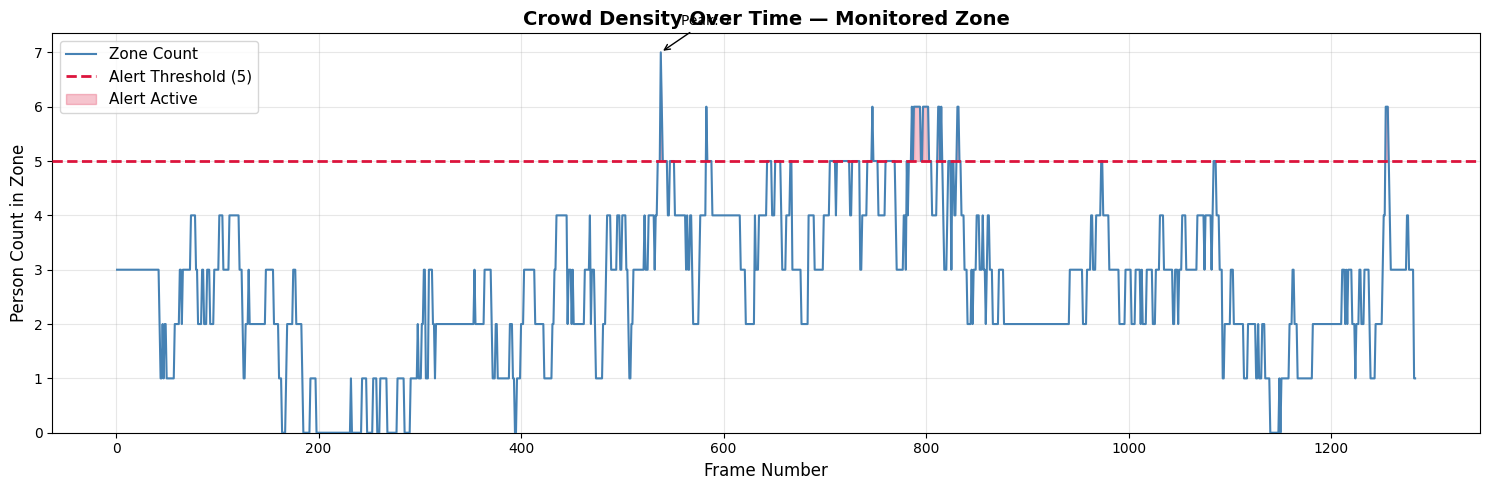

✅ Saved: density_over_time.png


In [20]:
frames_arr = [d[0] for d in density_over_time]
counts_arr = [d[1] for d in density_over_time]

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(frames_arr, counts_arr,
        color='steelblue', linewidth=1.5, label='Zone Count', zorder=3)

# Threshold line
ax.axhline(y=ALERT_THRESHOLD, color='crimson',
           linestyle='--', linewidth=2,
           label=f'Alert Threshold ({ALERT_THRESHOLD})', zorder=4)

# Red shading above threshold = alert periods
ax.fill_between(frames_arr, counts_arr, ALERT_THRESHOLD,
                where=[c > ALERT_THRESHOLD for c in counts_arr],
                color='crimson', alpha=0.25, label='Alert Active')

ax.set_xlabel('Frame Number', fontsize=12)
ax.set_ylabel('Person Count in Zone', fontsize=12)
ax.set_title('Crowd Density Over Time — Monitored Zone', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# Annotate peak
peak_frame = frames_arr[np.argmax(counts_arr)]
peak_count = max(counts_arr)
ax.annotate(f'Peak: {peak_count}',
            xy=(peak_frame, peak_count),
            xytext=(peak_frame + 20, peak_count + 0.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)

plt.tight_layout()
plt.savefig('density_over_time.png', dpi=150)
plt.show()
print("✅ Saved: density_over_time.png")

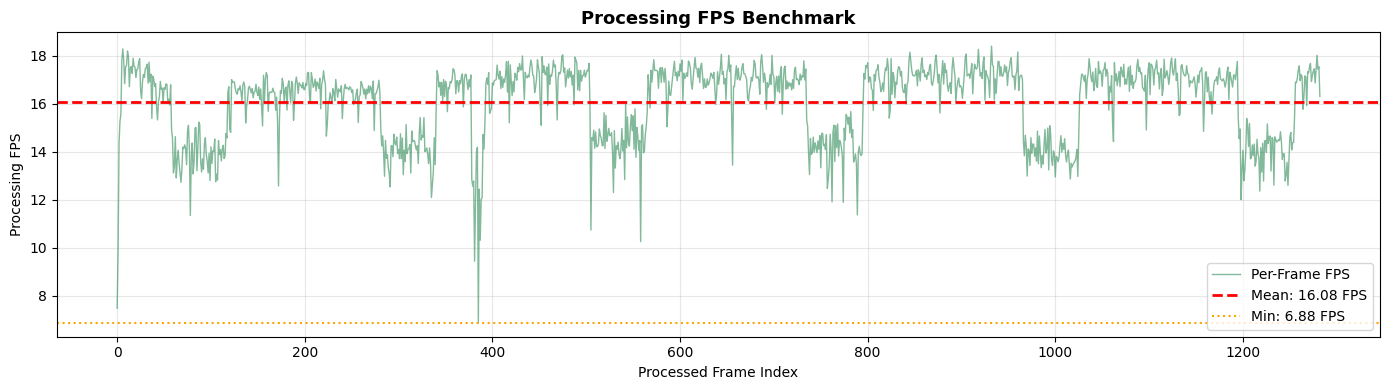

In [21]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(fps_log, color='seagreen', alpha=0.6, linewidth=1, label='Per-Frame FPS')
ax.axhline(y=np.mean(fps_log), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(fps_log):.2f} FPS')
ax.axhline(y=np.min(fps_log),  color='orange', linestyle=':', linewidth=1.5,
           label=f'Min: {np.min(fps_log):.2f} FPS')

ax.set_xlabel('Processed Frame Index')
ax.set_ylabel('Processing FPS')
ax.set_title('Processing FPS Benchmark', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fps_benchmark.png', dpi=150)
plt.show()

## 12. Download Results

In [22]:
print("📦 Downloading output files...")
files.download(OUTPUT_VIDEO)
files.download('density_over_time.png')
files.download('fps_benchmark.png')
files.download('classical_cv_analysis.png')
print("✅ All files downloaded.")

📦 Downloading output files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded.
